# 1. Asteroid Risk Prediction System - Exploratory Data Analysis

**Copyright © 2026 StellarMind - EarthGuard Asteroid Defense AI**  
**All Rights Reserved.**

**Authors**: Gouragopal Mohapatra & Arijit Kumar Mohanty  
**Project**: StellarMind - EarthGuard Asteroid Defense AI  
**Goal**: Understand NASA asteroid dataset structure, distributions, and identify risk patterns

**License**: This code and its contents are proprietary to StellarMind.  
Unauthorized copying, distribution, or use of this material is prohibited without prior written permission.

**Version**: 1.0 | **Date**: April 2026

In [42]:
# 2. Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [43]:
# 3. Load the raw NASA asteroid dataset
df = pd.read_csv('../data/raw/neo_dur_df.csv')
print(f"Dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

Dataset shape: (25869, 44)
Columns: ['Unnamed: 0', 'id', 'orbit_id', 'orbit_determination_date', 'first_observation_date', 'last_observation_date', 'data_arc_in_days', 'observations_used', 'orbit_uncertainty', 'minimum_orbit_intersection', 'jupiter_tisserand_invariant', 'epoch_osculation', 'eccentricity', 'semi_major_axis', 'inclination', 'ascending_node_longitude', 'orbital_period', 'perihelion_distance', 'perihelion_argument', 'aphelion_distance', 'perihelion_time', 'mean_anomaly', 'mean_motion', 'equinox', 'orbit_class_type', 'orbit_class_description', 'neo_reference_id', 'name', 'absolute_magnitude_h', 'estimated_diameter_kilometers_min', 'estimated_diameter_kilometers_max', 'is_potentially_hazardous_asteroid', 'orbiting_body0', 'miss_distance_kilometers0', 'relative_velocity0', 'orbiting_body1', 'miss_distance_kilometers1', 'relative_velocity1', 'orbiting_body2', 'miss_distance_kilometers2', 'relative_velocity2', 'orbiting_body3', 'miss_distance_kilometers3', 'relative_velocity3']

In [44]:
# 4. Display basic info and first few rows
print("=== Dataset Info ===")
df.info()
print("\n=== First 5 rows ===")
df.head()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25869 entries, 0 to 25868
Data columns (total 44 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Unnamed: 0                         25869 non-null  int64  
 1   id                                 25869 non-null  int64  
 2   orbit_id                           25869 non-null  int64  
 3   orbit_determination_date           25869 non-null  object 
 4   first_observation_date             25869 non-null  object 
 5   last_observation_date              25869 non-null  object 
 6   data_arc_in_days                   25732 non-null  float64
 7   observations_used                  25869 non-null  int64  
 8   orbit_uncertainty                  25869 non-null  int64  
 9   minimum_orbit_intersection         25869 non-null  float64
 10  jupiter_tisserand_invariant        25869 non-null  float64
 11  epoch_osculation                 

,Unnamed: 0,id,orbit_id,orbit_determination_date,first_observation_date,last_observation_date,data_arc_in_days,observations_used,orbit_uncertainty,minimum_orbit_intersection,...,relative_velocity0,orbiting_body1,miss_distance_kilometers1,relative_velocity1,orbiting_body2,miss_distance_kilometers2,relative_velocity2,orbiting_body3,miss_distance_kilometers3,relative_velocity3
0,0,2000433,659,2021-05-24 17:55:05,1893-10-29,2021-05-13,46582.0,9130,0,0.148353,...,5.578619,Earth,7.053323e+07,4.394491,Earth,7.468781e+07,4.816784,Earth,5.382329e+07,4.596055
1,1,2000719,272,2025-03-28 06:20:45,1911-10-04,2025-03-28,41449.0,2102,0,0.201318,...,3.446029,Juptr,2.119996e+08,3.263461,Juptr,2.223920e+08,3.724128,Juptr,2.930859e+08,5.004843
2,2,2001036,1392,2025-04-29 06:20:34,1924-10-23,2025-04-18,36702.0,12602,0,0.343339,...,6.303866,Juptr,2.928564e+08,6.672872,Mars,1.431039e+07,14.980296,Juptr,2.931775e+08,6.220393
3,3,2001221,143,2025-02-20 05:51:07,1932-03-12,2025-02-19,33947.0,686,0,0.107969,...,10.770174,Earth,2.026005e+07,9.557531,Earth,1.738689e+07,8.855631,Earth,1.613093e+07,8.394932
4,4,2001566,194,2025-08-19 08:22:05,1949-07-01,2025-08-18,27807.0,1792,0,0.033511,...,27.008056,Merc,1.486854e+07,42.897635,Earth,8.564701e+06,30.201259,Venus,1.992676e+07,30.445387


In [45]:
# 5. Check for missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing': missing, 'Percentage': missing_pct})
missing_df[missing_df['Missing'] > 0].sort_values('Percentage', ascending=False)

,Missing,Percentage
data_arc_in_days,137,0.529591


In [46]:
# 6. Statistical summary of numerical features
df.describe()

,Unnamed: 0,id,orbit_id,data_arc_in_days,observations_used,orbit_uncertainty,minimum_orbit_intersection,jupiter_tisserand_invariant,epoch_osculation,eccentricity,...,estimated_diameter_kilometers_min,estimated_diameter_kilometers_max,miss_distance_kilometers0,relative_velocity0,miss_distance_kilometers1,relative_velocity1,miss_distance_kilometers2,relative_velocity2,miss_distance_kilometers3,relative_velocity3
count,25869.000000,2.586900e+04,25869.000000,25732.000000,25869.000000,25869.000000,25869.000000,25869.000000,2.586900e+04,25869.000000,...,25869.000000,25869.000000,2.586900e+04,25869.000000,2.586900e+04,25869.000000,2.586900e+04,25869.000000,2.586900e+04,25869.000000
mean,12934.000000,2.283325e+07,24.854768,2016.016050,143.670958,3.911477,0.084978,4.537754,2.460759e+06,0.412514,...,0.159227,0.356042,5.188543e+07,13.579572,4.951420e+07,13.099874,4.930368e+07,13.107982,5.070780e+07,13.118764
std,7467.881393,2.472981e+07,49.857663,3426.837642,392.996340,3.087666,0.097548,1.173081,9.445307e+02,0.183680,...,0.388154,0.867938,6.033096e+07,7.621679,5.960718e+07,7.534610,5.928892e+07,7.515322,5.996734e+07,7.529046
min,0.000000,2.000433e+06,1.000000,1.000000,5.000000,0.000000,0.000001,-0.240000,2.448538e+06,0.003985,...,0.000511,0.001143,3.248862e+03,0.213417,9.711954e+03,0.126503,1.199075e+04,0.149565,7.726027e+03,0.282982
25%,6467.000000,3.556207e+06,6.000000,12.000000,34.000000,0.000000,0.010841,3.547000,2.461000e+06,0.268217,...,0.021113,0.047211,1.604831e+07,7.728140,1.468790e+07,7.490237,1.489265e+07,7.527200,1.582902e+07,7.423444
50%,12934.000000,3.798988e+06,11.000000,63.000000,59.000000,5.000000,0.044253,4.408000,2.461000e+06,0.413465,...,0.063761,0.142574,3.811716e+07,12.604474,3.485773e+07,11.941254,3.447627e+07,11.945557,3.627586e+07,11.978009
75%,19401.000000,5.422572e+07,24.000000,3306.250000,118.000000,7.000000,0.131040,5.329000,2.461000e+06,0.546757,...,0.191670,0.428588,6.193450e+07,18.092901,5.926964e+07,17.295585,5.897792e+07,17.221277,5.987431e+07,17.359047
max,25868.000000,5.454487e+07,1496.000000,46582.000000,14422.000000,9.000000,0.708340,11.624000,2.461000e+06,0.970464,...,38.775283,86.704169,2.991811e+08,76.029065,2.991441e+08,78.381080,2.991352e+08,83.256622,2.991187e+08,65.573369


In [47]:
# 7. Check target variable distribution
target_col = 'is_potentially_hazardous_asteroid'
print("Target Variable Distribution:")
print(df[target_col].value_counts())
print(f"\nPercentage Hazardous: {df[target_col].mean()*100:.2f}%")
print(f"Percentage Non-Hazardous: {(1-df[target_col].mean())*100:.2f}%")

Target Variable Distribution:
is_potentially_hazardous_asteroid
False    23370
True      2499
Name: count, dtype: int64

Percentage Hazardous: 9.66%
Percentage Non-Hazardous: 90.34%


In [48]:
# 8. Analyze asteroid orbit characteristics (corrected column names)
orbital_cols = ['eccentricity', 'semi_major_axis', 'inclination', 'ascending_node_longitude', 
                'orbital_period', 'perihelion_distance', 'perihelion_argument', 'aphelion_distance', 
                'mean_motion', 'orbit_uncertainty']
available_orbital = [col for col in orbital_cols if col in df.columns]

if available_orbital:
    print(f"Orbital columns available: {available_orbital}")
    print("\n=== Orbital Parameters Statistics ===")
    print(df[available_orbital].describe())
else:
    print("Checking available columns for orbital parameters...")
    orbital_like = [col for col in df.columns if any(term in col.lower() for term in ['orbit', 'axis', 'eccentric', 'inclination', 'perihelion', 'aphelion'])]
    print(f"Found these orbital-related columns: {orbital_like[:10]}")

Orbital columns available: ['eccentricity', 'semi_major_axis', 'inclination', 'ascending_node_longitude', 'orbital_period', 'perihelion_distance', 'perihelion_argument', 'aphelion_distance', 'mean_motion', 'orbit_uncertainty']

=== Orbital Parameters Statistics ===
       eccentricity  semi_major_axis   inclination  ascending_node_longitude  \
count  25869.000000     25869.000000  25869.000000              25869.000000   
mean       0.412514         1.633191     12.136003                173.487556   
std        0.183680         0.583212     10.493828                103.533201   
min        0.003985         0.461762      0.005998                  0.030542   
25%        0.268217         1.165905      4.594016                 82.911661   
50%        0.413465         1.500584      8.880284                172.760489   
75%        0.546757         2.080601     17.024528                256.207583   
max        0.970464         7.706718    165.603521                359.958995   

       orbita

In [49]:
# 9. Check correlations with target
target_col = 'is_potentially_hazardous_asteroid'

# Select only numeric columns and exclude the target itself for correlation matrix
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Ensure target is in numeric_cols and move it for correlation
if target_col in numeric_cols:
    # Calculate correlation with target
    correlations = df[numeric_cols].corr()[target_col].drop(target_col).sort_values(ascending=False)
    correlations_df = pd.DataFrame(correlations)
    correlations_df.columns = [f'Correlation with {target_col}']
    
    print("=== Top 10 Positive Correlations ===")
    print(correlations_df.head(10))
    print("\n=== Top 10 Negative Correlations ===")
    print(correlations_df.tail(10))
else:
    print(f"Target column '{target_col}' not found in numeric columns")
    print(f"Available numeric columns: {numeric_cols[:10]}")

Target column 'is_potentially_hazardous_asteroid' not found in numeric columns
Available numeric columns: ['Unnamed: 0', 'id', 'orbit_id', 'data_arc_in_days', 'observations_used', 'orbit_uncertainty', 'minimum_orbit_intersection', 'jupiter_tisserand_invariant', 'epoch_osculation', 'eccentricity']


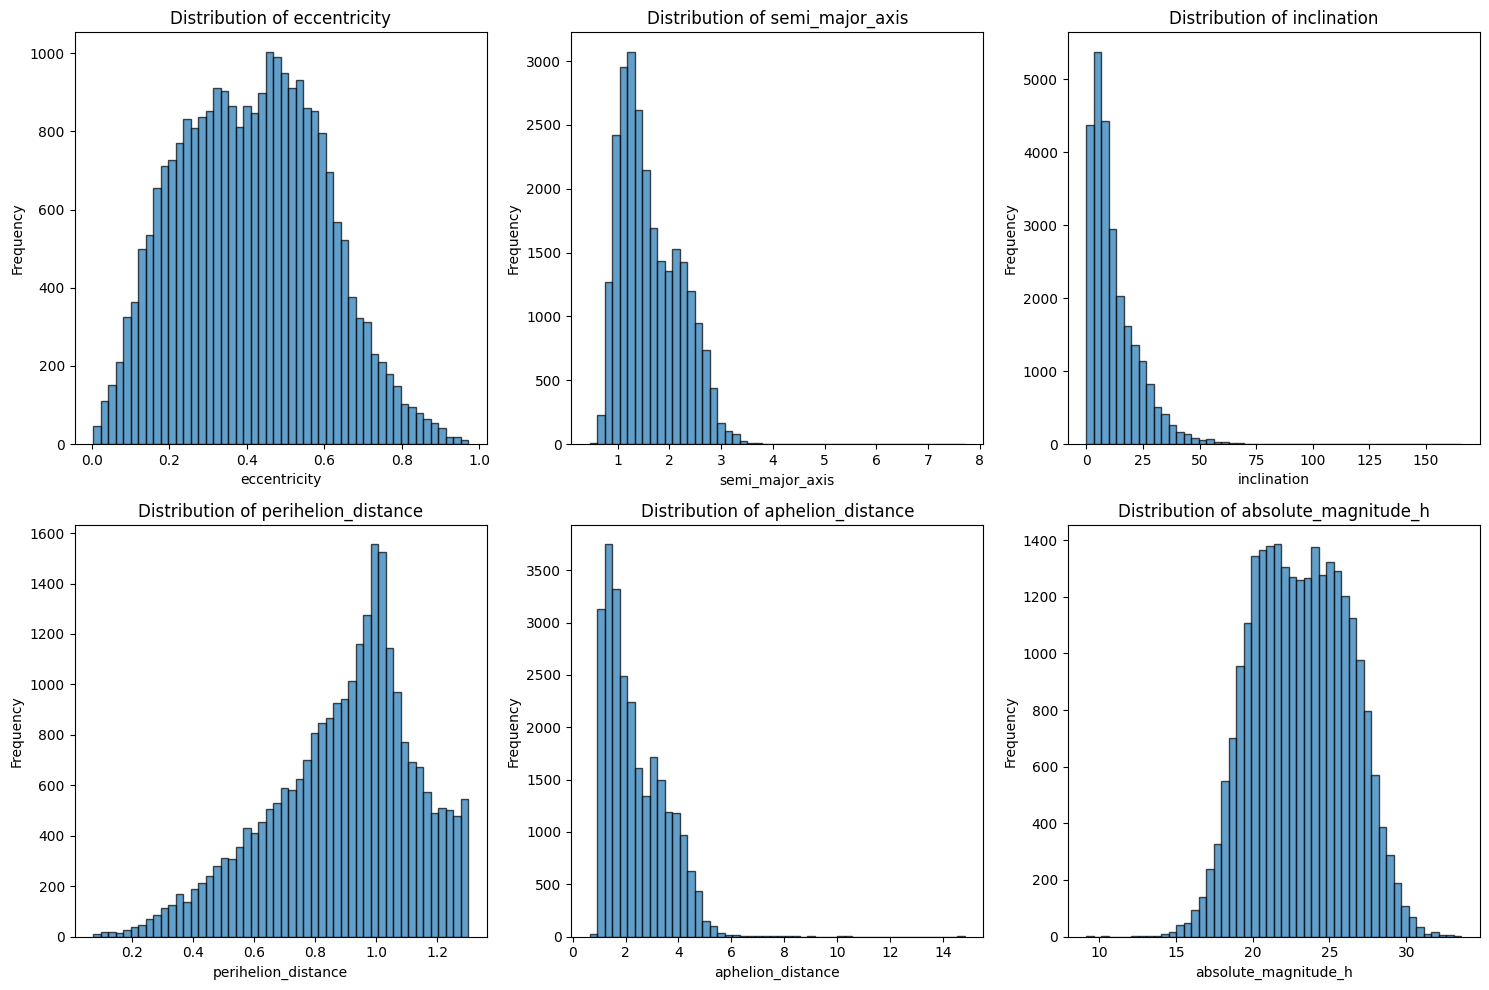

In [50]:
# 10. Visualize distributions of key numerical features
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
features_to_plot = ['eccentricity', 'semi_major_axis', 'inclination', 'perihelion_distance', 'aphelion_distance', 'absolute_magnitude_h']
available_features = [f for f in features_to_plot if f in df.columns]

for idx, feature in enumerate(available_features[:6]):
    row, col = idx // 3, idx % 3
    axes[row, col].hist(df[feature].dropna(), bins=50, edgecolor='black', alpha=0.7)
    axes[row, col].set_title(f'Distribution of {feature}')
    axes[row, col].set_xlabel(feature)
    axes[row, col].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

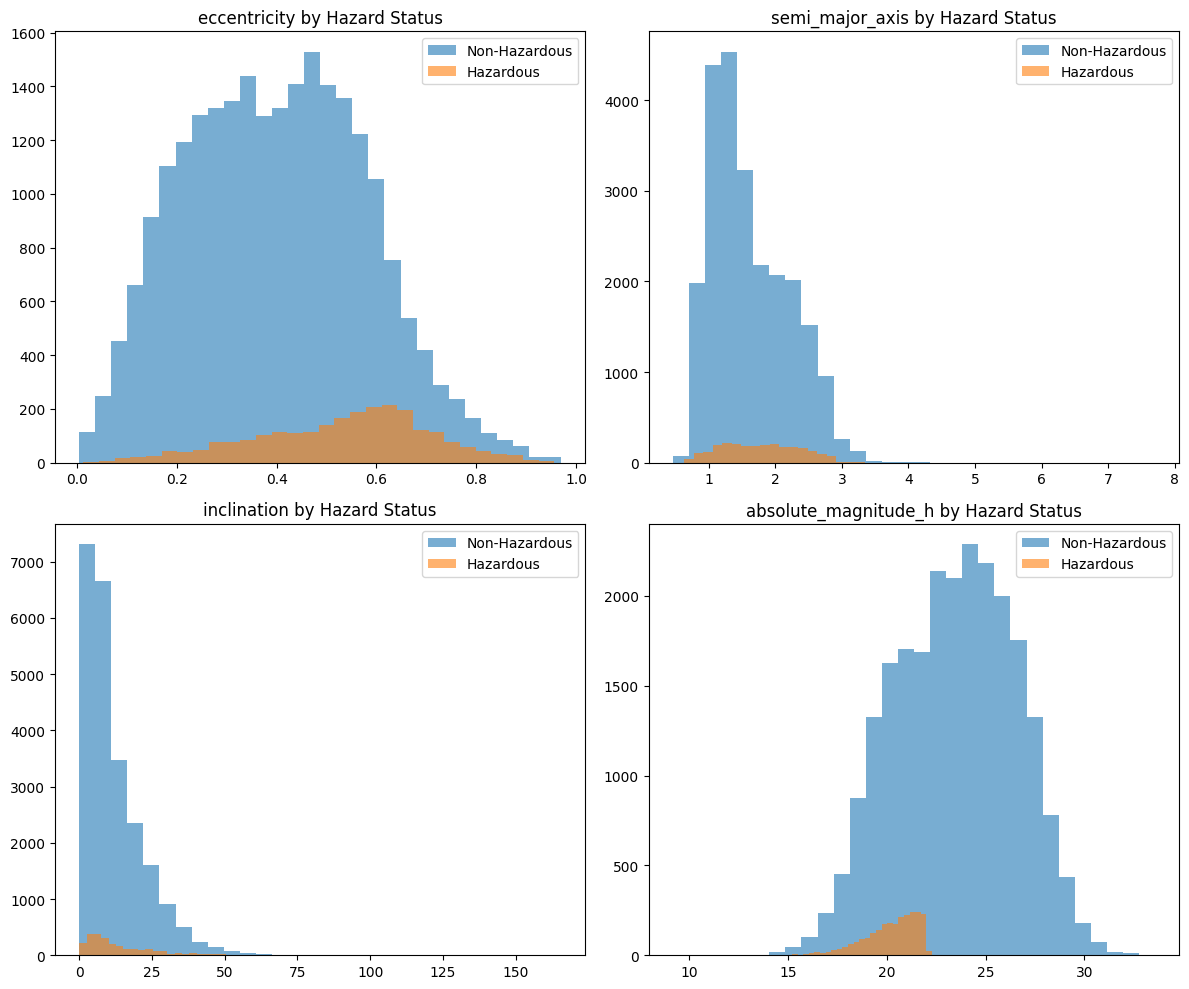

In [51]:
# 11. Hazardous vs Non-hazardous comparison
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
top_features = ['eccentricity', 'semi_major_axis', 'inclination', 'absolute_magnitude_h']
available_top = [f for f in top_features if f in df.columns]

for idx, feature in enumerate(available_top[:4]):
    row, col = idx // 2, idx % 2
    for hazard_val in [0, 1]:
        subset = df[df[target_col] == hazard_val]
        label = 'Non-Hazardous' if hazard_val == 0 else 'Hazardous'
        axes[row, col].hist(subset[feature].dropna(), bins=30, alpha=0.6, label=label)
        axes[row, col].set_title(f'{feature} by Hazard Status')
        axes[row, col].legend()
plt.tight_layout()
plt.show()

In [52]:
# 12. Detect outliers using IQR method
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

print("=== Outlier Detection (IQR Method) ===")
for col in available_orbital[:6]:
    if col in df.columns:
        n_outliers, lb, ub = detect_outliers_iqr(df, col)
        outlier_pct = (n_outliers / len(df)) * 100
        print(f"{col}: {n_outliers} outliers ({outlier_pct:.2f}%) | bounds: [{lb:.4f}, {ub:.4f}]")

=== Outlier Detection (IQR Method) ===
eccentricity: 3 outliers (0.01%) | bounds: [-0.1496, 0.9646]
semi_major_axis: 40 outliers (0.15%) | bounds: [-0.2061, 3.4526]
inclination: 947 outliers (3.66%) | bounds: [-14.0518, 35.6703]
ascending_node_longitude: 0 outliers (0.00%) | bounds: [-177.0322, 516.1515]
orbital_period: 183 outliers (0.71%) | bounds: [-494.7048, 2050.7104]
perihelion_distance: 303 outliers (1.17%) | bounds: [0.2869, 1.5057]


In [53]:
# 13. Check for duplicate rows
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
if duplicates > 0:
    print("Removing duplicates for clean analysis...")
    df = df.drop_duplicates()
    print(f"New shape after removing duplicates: {df.shape}")

Number of duplicate rows: 0


In [54]:
# 14. Identify data types and potential encoding needs
print("=== Column Data Types ===")
print(df.dtypes.value_counts())
print("\n=== Categorical/Object Columns ===")
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical columns: {cat_cols[:10]}")
print(f"Total categorical columns: {len(cat_cols)}")

=== Column Data Types ===
float64    26
object     11
int64       6
bool        1
Name: count, dtype: int64

=== Categorical/Object Columns ===
Categorical columns: ['orbit_determination_date', 'first_observation_date', 'last_observation_date', 'equinox', 'orbit_class_type', 'orbit_class_description', 'name', 'orbiting_body0', 'orbiting_body1', 'orbiting_body2']
Total categorical columns: 11


In [55]:
# 15. Summary statistics for hazardous vs non-hazardous (grouped)
print("=== Grouped Statistics (Hazardous vs Non-Hazardous) ===")
group_stats = df.groupby(target_col)[available_orbital[:8]].mean()
group_stats.index = ['Non-Hazardous', 'Hazardous']
print(group_stats.round(4))

=== Grouped Statistics (Hazardous vs Non-Hazardous) ===
               eccentricity  semi_major_axis  inclination  \
Non-Hazardous        0.3997           1.6176      11.9197   
Hazardous            0.5324           1.7790      14.1588   

               ascending_node_longitude  orbital_period  perihelion_distance  \
Non-Hazardous                  173.4213        786.8714               0.9015   
Hazardous                      174.1069        902.0415               0.7667   

               perihelion_argument  aphelion_distance  
Non-Hazardous             181.2929             2.3337  
Hazardous                 179.5912             2.7913  


In [57]:
# 16. Key insights from EDA
print("=== KEY INSIGHTS ===")
print(f"1. Dataset contains {df.shape[0]} asteroids with {df.shape[1]} features")
print(f"2. Hazardous asteroids: {df[target_col].sum()} ({df[target_col].mean()*100:.2f}%)")
print(f"3. Non-Hazardous asteroids: {(df[target_col] == 0).sum()} ({(1-df[target_col].mean())*100:.2f}%)")
print("4. Orbital eccentricity and semi-major axis show significant differences between classes")

# Recalculate missing values for insight
missing_count = df.isnull().sum()
missing_cols_count = (missing_count > 0).sum()
print(f"5. Missing values found in {missing_cols_count} columns - need preprocessing")

print("6. Outliers present in orbital parameters - consider robust scaling")
print("7. Features ready for RF, DT, and Regression models")

=== KEY INSIGHTS ===
1. Dataset contains 25869 asteroids with 44 features
2. Hazardous asteroids: 2499 (9.66%)
3. Non-Hazardous asteroids: 23370 (90.34%)
4. Orbital eccentricity and semi-major axis show significant differences between classes
5. Missing values found in 1 columns - need preprocessing
6. Outliers present in orbital parameters - consider robust scaling
7. Features ready for RF, DT, and Regression models


In [58]:
# 17. Save processed data for next notebook (no images saved to reports)
df.to_csv('../data/processed/asteroid_cleaned.csv', index=False)
print("✓ Cleaned data saved to '../data/processed/asteroid_cleaned.csv'")
print(f"✓ Shape: {df.shape}")
print(f"✓ Target column: {target_col}")

✓ Cleaned data saved to '../data/processed/asteroid_cleaned.csv'
✓ Shape: (25869, 44)
✓ Target column: is_potentially_hazardous_asteroid


In [59]:
# 18. Display final variable info for next steps
print("=== VARIABLES READY FOR MODELLING ===")
features_to_use = [col for col in numeric_cols if col != target_col]
print(f"Total features available: {len(features_to_use)}")
print(f"Sample features: {features_to_use[:15]}")
print(f"\nTarget variable: {target_col}")
print(f"Models to implement: Random Forest, Decision Tree, Regression (Linear/Logistic)")
print("\n--- Next Notebook: 02_preprocessing.ipynb ---")

=== VARIABLES READY FOR MODELLING ===
Total features available: 32
Sample features: ['Unnamed: 0', 'id', 'orbit_id', 'data_arc_in_days', 'observations_used', 'orbit_uncertainty', 'minimum_orbit_intersection', 'jupiter_tisserand_invariant', 'epoch_osculation', 'eccentricity', 'semi_major_axis', 'inclination', 'ascending_node_longitude', 'orbital_period', 'perihelion_distance']

Target variable: is_potentially_hazardous_asteroid
Models to implement: Random Forest, Decision Tree, Regression (Linear/Logistic)

--- Next Notebook: 02_preprocessing.ipynb ---


---
## Copyright Notice

**© 2026 StellarMind - EarthGuard Asteroid Defense AI. All Rights Reserved.**

This notebook and its contents are the intellectual property of StellarMind.  
No part of this code may be reproduced, distributed, or transmitted in any form without prior written permission from the authors.

**Authors**: Gouragopal Mohapatra & Arijit Kumar Mohanty  
**Project**: Asteroid Risk Prediction System

**Last Updated**: April 2026